# 🧊 บทที่ 04 — Gridding: จาก PPI สู่กริดคาร์ทีเซียน, CAPPI และวิธี Interpolation (ฉบับขยาย)
### หลักสูตรแลปเรดาร์ตรวจอากาศด้วย Py-ART และ wradlib

**ระดับ:** ขั้นกลาง  |  **ต้องมีก่อน:** รันบทที่ 00 แล้ว (แนะนำผ่านบท 03 เรื่อง gate filter มาก่อน)

การแปลงข้อมูลโพลาร์ (มุม–ระยะ) เป็น **กริดคาร์ทีเซียน** เป็นหัวใจของการทำแผนที่และการวิเคราะห์เชิงพื้นที่ บทนี้ให้นิสิต **ทดลองเล่น** กับวิธี interpolation, ปรากฏการณ์ **cone of silence**, ผลของ **รัศมี (radius/ROI)**, ความละเอียดกริด และผลิตภัณฑ์ต่อยอด ผ่าน 10 ตัวอย่างต่อเนื่อง

**เส้นเรื่องของบท (ร้อยเรียง):**
| # | หัวข้อ |
|---|---|
| A1 | Gridding พื้นฐาน: PPI → CAPPI ระดับเดียว |
| A2 | กริด 3 มิติ → ดึงหลายระดับ CAPPI (1/2/3/5 กม.) |
| A3 | เทียบ PPI vs CAPPI |
| A4 | Cone of silence — เห็นรูเหนือสถานีจากภาพตัดแนวดิ่ง |
| A5 | การเติม (fill) บริเวณ cone of silence |
| A6 | เทียบวิธี interpolation: Barnes2 / Cressman / Nearest |
| A7 | ผลของรัศมี ROI ต่างกัน (เล็ก↔ใหญ่) |
| A8 | ผลของความละเอียดกริด (2/1/0.5 กม.) + เวลา |
| A9 | ผลิตภัณฑ์ Composite (Column-max reflectivity) |
| A10 | ภาพตัดแนวดิ่งจากกริด 3 มิติ (สะพานสู่บท 05) |

---


## 🧠 หลักการเบื้องต้น

ข้อมูลเรดาร์ดิบอยู่ในพิกัด **โพลาร์** (แต่ละ ray มีหลาย gate) การนำไปทำแผนที่/ซ้อน GIS/คำนวณเชิงพื้นที่ ต้อง **แปลงเป็นกริดคาร์ทีเซียนสม่ำเสมอ** ผ่านการ *interpolation*

- **CAPPI (Constant Altitude PPI)** = การตัดกริด 3 มิติที่ระดับความสูงคงที่
- **Cone of silence** = "รู" เหนือสถานีที่ตรวจไม่ถึง เพราะมุมยกสูงสุดของเรดาร์ไม่ถึง 90° (บีมพุ่งเฉียง ไม่ตั้งฉาก)
- **วิธี interpolation** ใน Py-ART: `Barnes2` (ถ่วงน้ำหนักแบบเกาส์เซียน), `Cressman` (ถ่วงตามระยะ), `Nearest` (เพื่อนบ้านใกล้สุด)
- **รัศมีอิทธิพล (ROI / radius of influence)** = รัศมีที่จุดข้อมูลรอบ ๆ มีผลต่อค่ากริด — ใหญ่ → เรียบ, เล็ก → คมชัดแต่มีรู

การเลือกวิธี/รัศมี/ความละเอียด มีผลต่อความเรียบ–รายละเอียด–เวลาในการคำนวณ ซึ่งบทนี้จะให้เห็นเชิงประจักษ์


## ⚙️ ส่วนหัวมาตรฐาน (ติดตั้งไลบรารี + เชื่อม Drive + ฟอนต์ไทย)


In [ ]:
%pip install -q arm_pyart

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.8/157.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 53.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the 

In [ ]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
import pyart
import warnings; warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
ROOT = '/content/drive/MyDrive/tmd_radar_course'
sys.path.append(os.path.join(ROOT, '9config'))
import course_paths as P
assert os.path.exists(P.RADAR_1000), "⚠️ ไม่พบข้อมูลเรดาร์ — กรุณารัน Notebook 00 ก่อน"
OUT = P.results_dir('lesson04')
print("พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่:", OUT)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

Mounted at /content/drive
พร้อมแล้ว ✅  ผลลัพธ์บันทึกที่: /content/drive/MyDrive/tmd_radar_course/1results/lesson04


### 🔤 ติดตั้งฟอนต์ไทยสำหรับกราฟ (จำเป็น — มิฉะนั้นข้อความไทยจะแสดงเป็นกล่อง □□□)

ดาวน์โหลดฟอนต์ **Sarabun** (ฟอนต์ราชการไทย เหมาะงานตีพิมพ์) มาลงทะเบียนกับ matplotlib พร้อมตั้งสไตล์กราฟระดับตีพิมพ์ — รันเซลล์นี้ก่อนพลอตทุกครั้ง

In [ ]:
# ── ติดตั้ง & ตั้งค่าฟอนต์ไทยให้ matplotlib (ต้องรันก่อนพลอตกราฟที่มีข้อความไทย) ──
import os, glob, subprocess, urllib.request
import matplotlib as mpl, matplotlib.pyplot as plt, matplotlib.font_manager as fm

def setup_thai_font(verbose=True):
    d = '/usr/share/fonts/truetype/sarabun'; os.makedirs(d, exist_ok=True)
    # 1) Sarabun จาก Google Fonts (ฟอนต์ราชการไทย)
    if not glob.glob(d + '/*.ttf'):
        base = 'https://github.com/google/fonts/raw/main/ofl/sarabun/'
        for fn in ('Sarabun-Regular.ttf', 'Sarabun-Bold.ttf'):
            try: urllib.request.urlretrieve(base + fn, os.path.join(d, fn))
            except Exception: pass
    # 2) สำรอง: ฟอนต์ไทย TLWG ผ่าน apt (มีใน Colab เสมอ)
    if not glob.glob(d + '/*.ttf') and not glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        subprocess.run(['apt-get', '-qq', '-y', 'install', 'fonts-thai-tlwg'], capture_output=True)
    # ลงทะเบียนฟอนต์ที่ติดตั้ง
    for fp in glob.glob(d + '/*.ttf') + glob.glob('/usr/share/fonts/truetype/tlwg/*.ttf'):
        try: fm.fontManager.addfont(fp)
        except Exception: pass
    avail = {f.name for f in fm.fontManager.ttflist}
    chosen = next((n for n in ('Sarabun','Loma','Garuda','Norasi') if n in avail), None)
    if chosen: mpl.rcParams['font.family'] = chosen
    mpl.rcParams['axes.unicode_minus'] = False
    if verbose:
        print('ฟอนต์ไทยที่ใช้:', chosen or 'ไม่พบ — ลองรันเซลล์นี้อีกครั้งหลังติดตั้ง')
    return chosen

setup_thai_font()
# สไตล์กราฟระดับตีพิมพ์ (ฟอนต์ใหญ่ อ่านง่าย)
plt.rcParams.update({'figure.dpi':120, 'savefig.dpi':300, 'font.size':13,
    'axes.titlesize':16, 'axes.labelsize':14, 'xtick.labelsize':12,
    'ytick.labelsize':12, 'legend.fontsize':13, 'axes.unicode_minus':False})

ฟอนต์ไทยที่ใช้: Sarabun


In [ ]:
# อ่าน + กรองคุณภาพ (บท 03) เตรียม gate filter ใช้ตลอดบท
radar = pyart.io.read(P.RADAR_1000)
gf = pyart.filters.GateFilter(radar)
gf.exclude_below('cross_correlation_ratio', 0.80)
gf.exclude_below('reflectivity', 0.0)

HALF = 240000.0   # ครึ่งช่วงกริด (m) = รัศมี 240 กม.

def make_grid(n_xy=241, nz=1, zlim=(2000., 2000.),
              weighting='Barnes2', roi_func='dist_beam', constant_roi=None):
    "สร้างกริดคาร์ทีเซียนจากเรดาร์ (คืน pyart Grid)"
    return pyart.map.grid_from_radars(
        (radar,), gatefilters=(gf,),
        grid_shape=(nz, n_xy, n_xy),
        grid_limits=(zlim, (-HALF, HALF), (-HALF, HALF)),
        fields=['reflectivity'],
        weighting_function=weighting,
        roi_func=roi_func, constant_roi=constant_roi)

def show(ax, arr, title, extent=(-240,240,-240,240), vmin=-10, vmax=60):
    pm = ax.imshow(arr, origin='lower', extent=extent, cmap='NWSRef', vmin=vmin, vmax=vmax)
    ax.set_title(title); ax.set_xlabel('กม.'); ax.set_ylabel('กม.'); ax.set_aspect('equal')
    plt.colorbar(pm, ax=ax, shrink=0.8, label='dBZ'); return pm

print("เตรียมฟังก์ชัน gridding แล้ว ✅")

เตรียมฟังก์ชัน gridding แล้ว ✅


---
## A1 — Gridding พื้นฐาน: PPI → CAPPI ระดับเดียว (2 กม.)


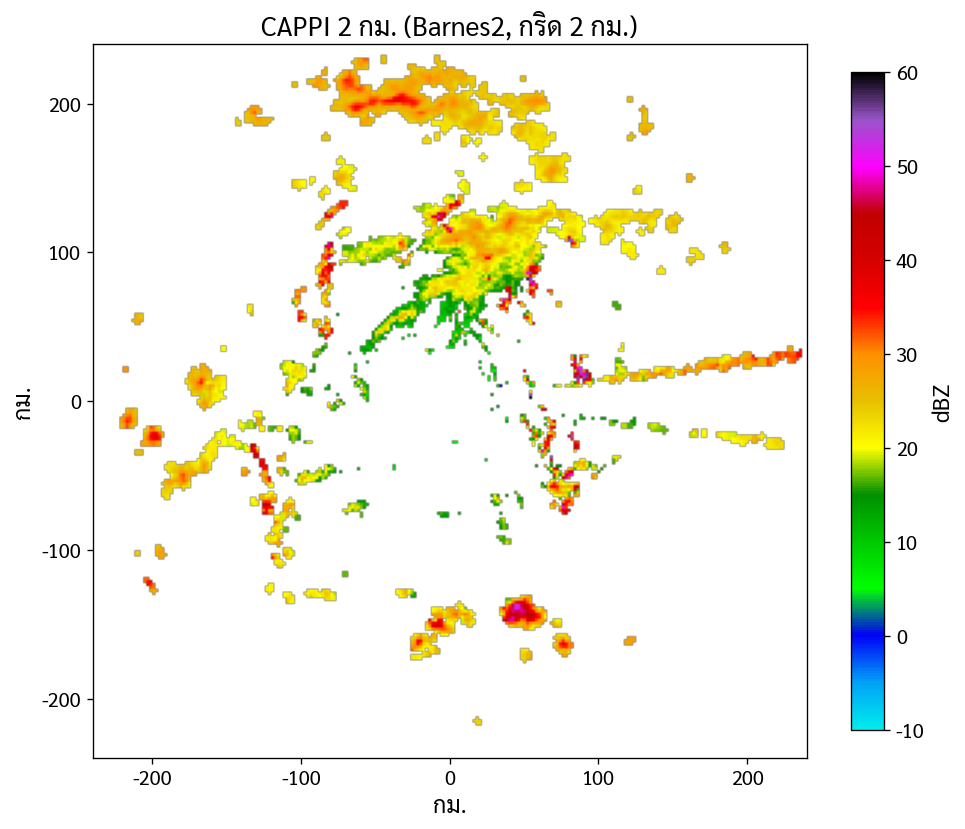

In [ ]:
grid = make_grid(n_xy=241, nz=1, zlim=(2000., 2000.))
cappi2 = np.ma.filled(grid.fields['reflectivity']['data'][0], np.nan)

fig, ax = plt.subplots(figsize=(8.5, 7.5))
show(ax, cappi2, 'CAPPI 2 กม. (Barnes2, กริด 2 กม.)')
plt.tight_layout(); plt.show()

**การแปลผล:** ได้ภาพฝนบนกริดสม่ำเสมอ พร้อมนำไปทำแผนที่ (บท 06) หรือคำนวณ QPE (บท 08)


## A2 — กริด 3 มิติ → ดึงหลายระดับ CAPPI

สร้างกริด 3 มิติครั้งเดียว แล้วตัดหลายระดับความสูง เพื่อดูโครงสร้างฝนตามความสูง


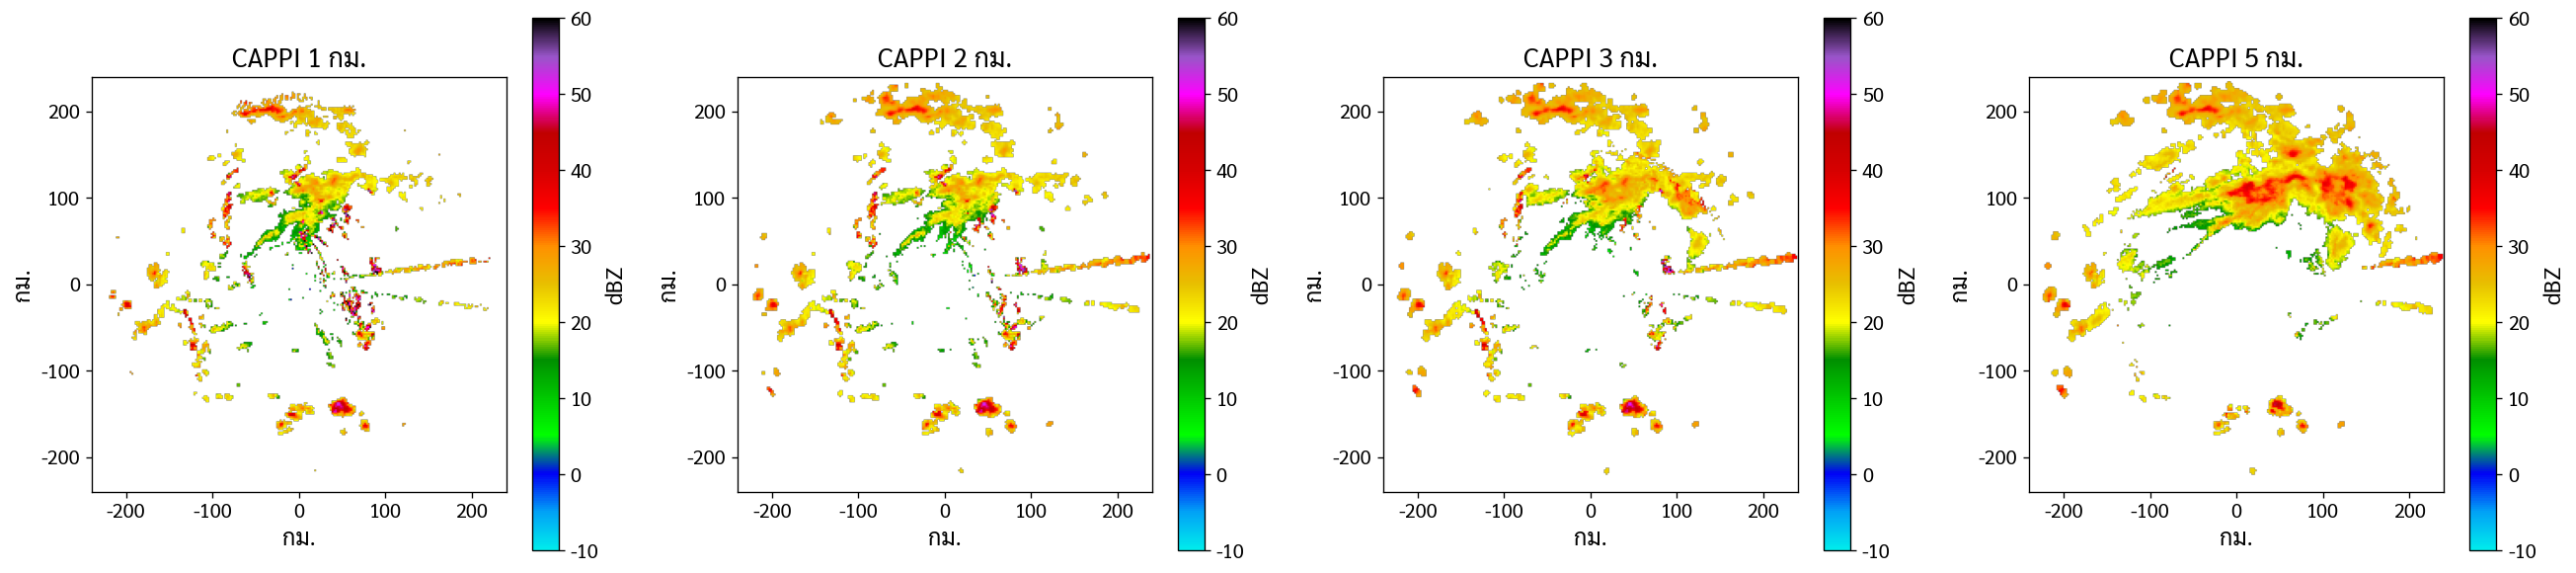

In [ ]:
grid3d = make_grid(n_xy=241, nz=16, zlim=(1000., 16000.))   # 1–16 กม. ทีละ 1 กม.
z_levels = np.linspace(1000., 16000., 16)
vol = np.ma.filled(grid3d.fields['reflectivity']['data'], np.nan)   # (nz, ny, nx)

wanted = [1000., 2000., 3000., 5000.]
idx = [int(np.argmin(np.abs(z_levels - w))) for w in wanted]
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
for ax, k in zip(axes, idx):
    show(ax, vol[k], f'CAPPI {z_levels[k]/1000:.0f} กม.')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A2_cappi_levels.png'), dpi=200, bbox_inches='tight')
plt.show()

**การแปลผล:** ที่ระดับต่ำเห็นฝนกว้าง เมื่อสูงขึ้นเหลือเฉพาะแกนพายุที่ยกตัวสูง — สะท้อนโครงสร้างแนวดิ่งของพายุ


## A3 — เทียบ PPI vs CAPPI

PPI = มุมยกคงที่ (ความสูงเพิ่มตามระยะ); CAPPI = ความสูงคงที่ (รวมหลายมุมยก)


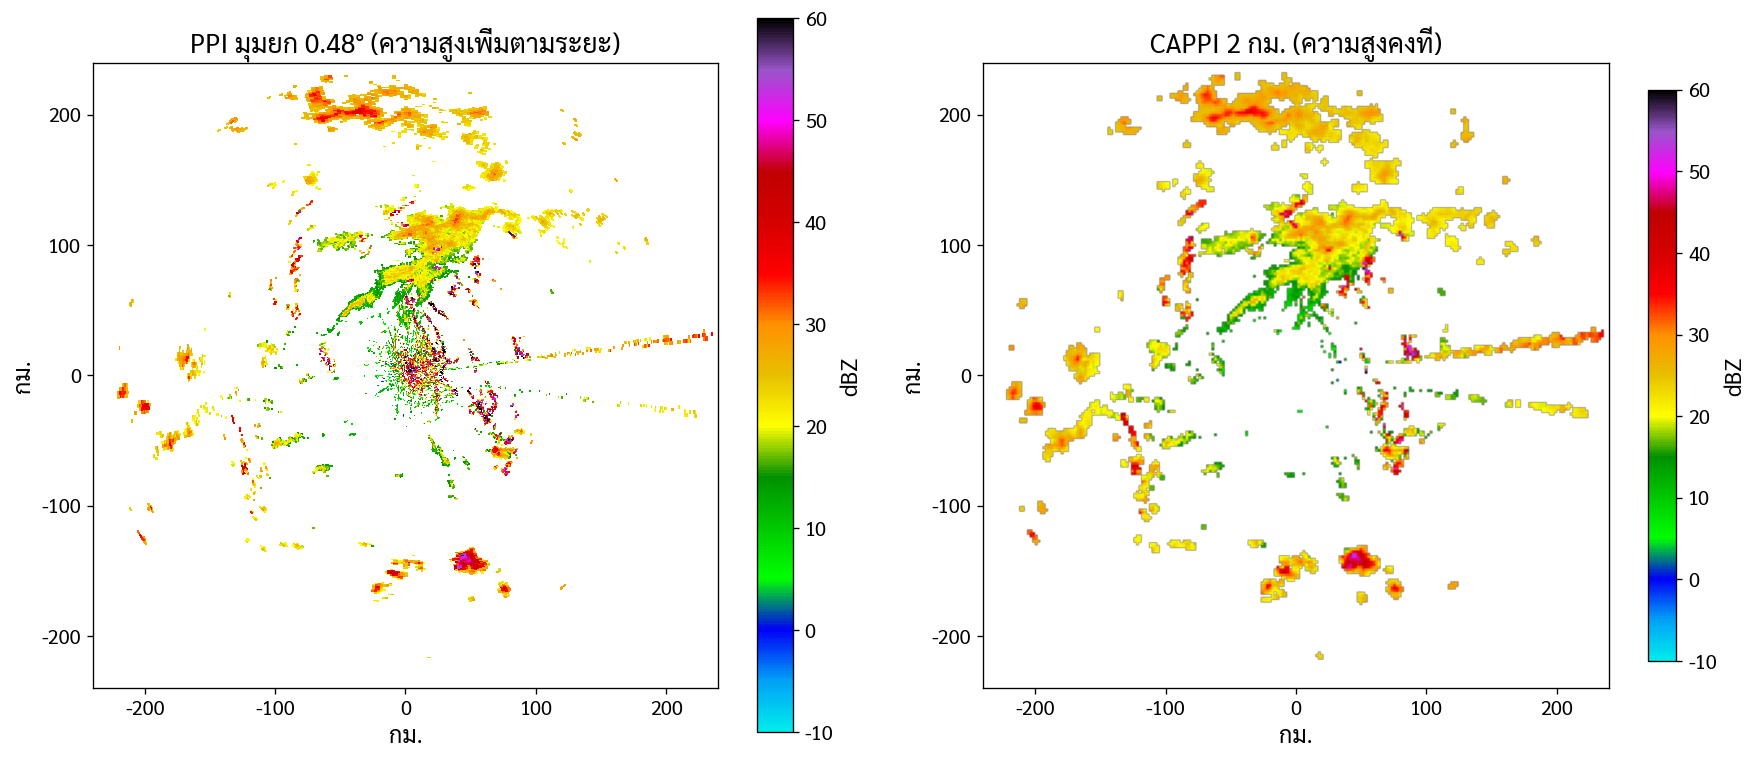

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
d = pyart.graph.RadarDisplay(radar)
d.plot('reflectivity', sweep=0, ax=axes[0], vmin=-10, vmax=60, cmap='NWSRef',
       gatefilter=gf, colorbar_label='dBZ',
       title=f'PPI มุมยก {float(radar.fixed_angle["data"][0]):.2f}° (ความสูงเพิ่มตามระยะ)')
axes[0].set_xlim(-240,240); axes[0].set_ylim(-240,240); axes[0].set_aspect('equal')
axes[0].set_xlabel('กม.'); axes[0].set_ylabel('กม.')
show(axes[1], cappi2, 'CAPPI 2 กม. (ความสูงคงที่)')
plt.tight_layout(); plt.show()

**การแปลผล:** ที่ระยะไกล PPI อยู่สูงกว่า 2 กม. จึงเห็นต่างจาก CAPPI — CAPPI เหมาะกับการเทียบฝนที่ "ระดับเดียวกัน" ทั่วพื้นที่


## A4 — Cone of Silence: เห็น "รู" เหนือสถานีจากภาพตัดแนวดิ่ง

ตัดกริด 3 มิติตามแนวผ่านสถานี (แกน x ที่ y=0) จะเห็นบริเวณไร้ข้อมูลรูปกรวยเหนือสถานี


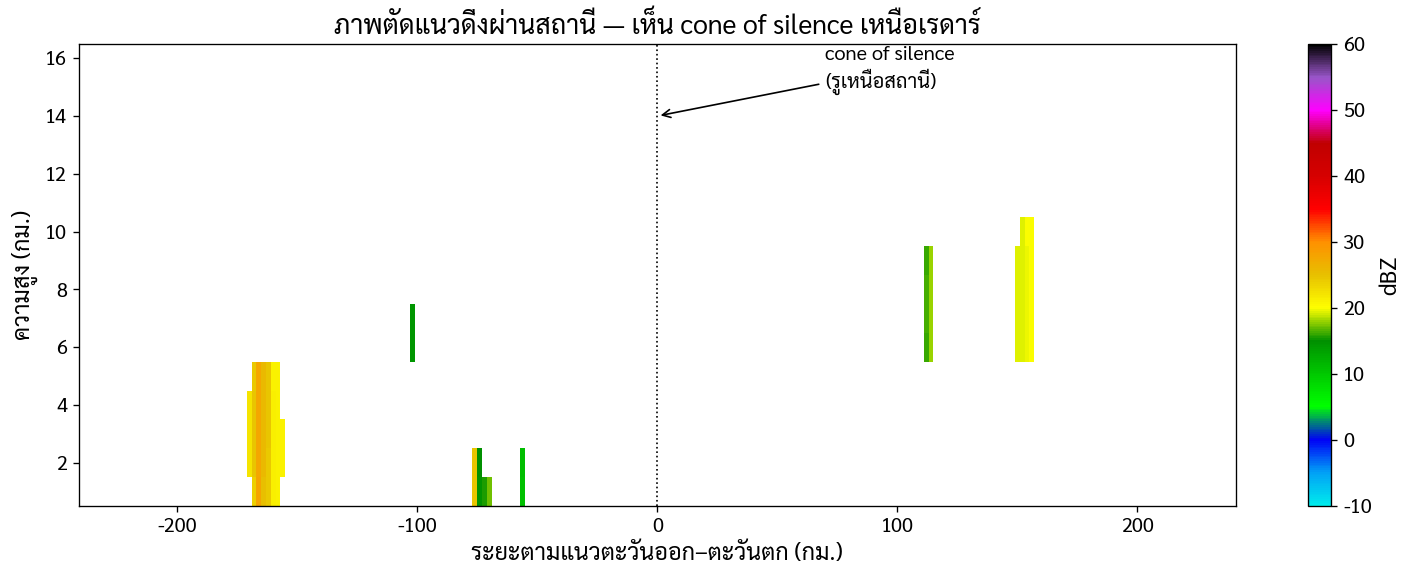

In [ ]:
ny = vol.shape[1]; jc = ny // 2                 # แถวกลาง (y ≈ 0 ผ่านสถานี)
xz = vol[:, jc, :]                               # (nz, nx) ภาพตัดแนวดิ่ง
xkm = np.linspace(-240, 240, vol.shape[2]); zkm = z_levels/1000

fig, ax = plt.subplots(figsize=(13, 5))
pm = ax.pcolormesh(xkm, zkm, np.ma.masked_invalid(xz), cmap='NWSRef', vmin=-10, vmax=60, shading='auto')
ax.axvline(0, color='k', ls=':', lw=1)
ax.annotate('cone of silence\n(รูเหนือสถานี)', xy=(0, zkm[-3]), xytext=(70, zkm[-2]),
            arrowprops=dict(arrowstyle='->'), fontsize=12, ha='left')
ax.set_xlabel('ระยะตามแนวตะวันออก–ตะวันตก (กม.)'); ax.set_ylabel('ความสูง (กม.)')
ax.set_title('ภาพตัดแนวดิ่งผ่านสถานี — เห็น cone of silence เหนือเรดาร์')
plt.colorbar(pm, ax=ax, label='dBZ')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A4_cone_of_silence.png'), dpi=200, bbox_inches='tight')
plt.show()

**การแปลผล:** เหนือสถานี (x≈0) ที่ระดับสูงจะเป็นช่องว่าง เพราะมุมยกสูงสุดไม่ถึง 90° ลำบีมจึงพุ่งเฉียงเลยยอดสถานีไป


## A5 — การเติม (fill) บริเวณ Cone of Silence

การเพิ่ม **รัศมีอิทธิพลคงที่ (constant ROI) ให้ใหญ่ขึ้น** หรือใช้ `Nearest` ช่วยดึงค่าจากบริเวณข้างเคียงมาเติมช่องว่างได้บางส่วน (แต่เป็นการประมาณ ไม่ใช่ค่าจริง)


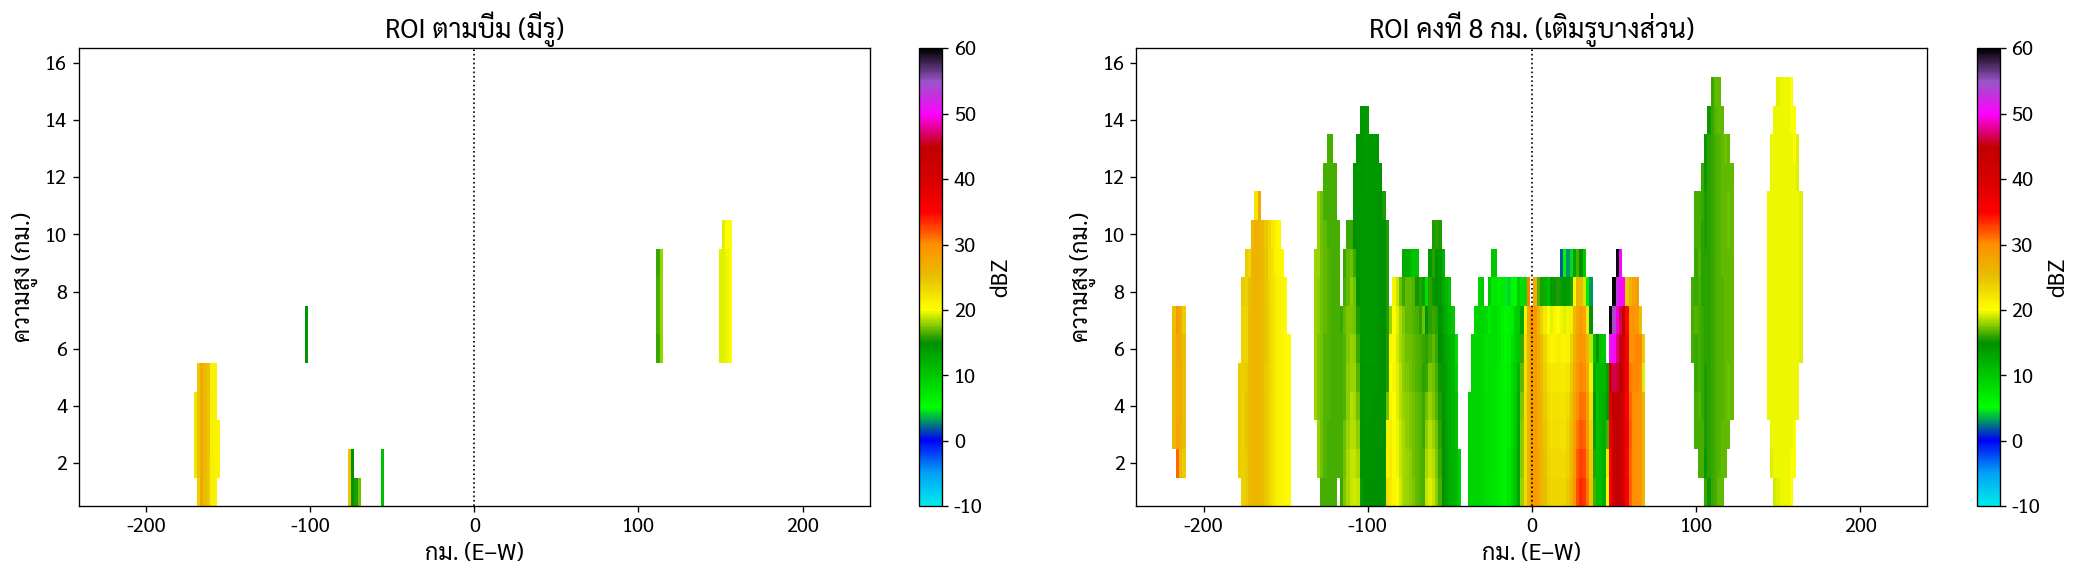

In [ ]:
grid_fill = make_grid(n_xy=241, nz=16, zlim=(1000., 16000.),
                       roi_func='constant', constant_roi=8000.)   # ROI ใหญ่ 8 กม.
vol_fill = np.ma.filled(grid_fill.fields['reflectivity']['data'], np.nan)
xz_fill = vol_fill[:, jc, :]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, arr, t in zip(axes, [xz, xz_fill],
                      ['ROI ตามบีม (มีรู)', 'ROI คงที่ 8 กม. (เติมรูบางส่วน)']):
    pm = ax.pcolormesh(xkm, zkm, np.ma.masked_invalid(arr), cmap='NWSRef', vmin=-10, vmax=60, shading='auto')
    ax.axvline(0, color='k', ls=':', lw=1); ax.set_title(t)
    ax.set_xlabel('กม. (E–W)'); ax.set_ylabel('ความสูง (กม.)')
    plt.colorbar(pm, ax=ax, label='dBZ')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A5_fill_cone.png'), dpi=200, bbox_inches='tight')
plt.show()

**การแปลผล:** ROI ใหญ่ช่วยลดช่องว่าง แต่ทำให้ภาพเรียบเบลอขึ้น — เป็น trade-off ที่ต้องเลือกตามการใช้งาน (อย่าลืมว่าค่าที่เติมเป็นการประมาณ)


## A6 — เทียบวิธี Interpolation: Barnes2 / Cressman / Nearest


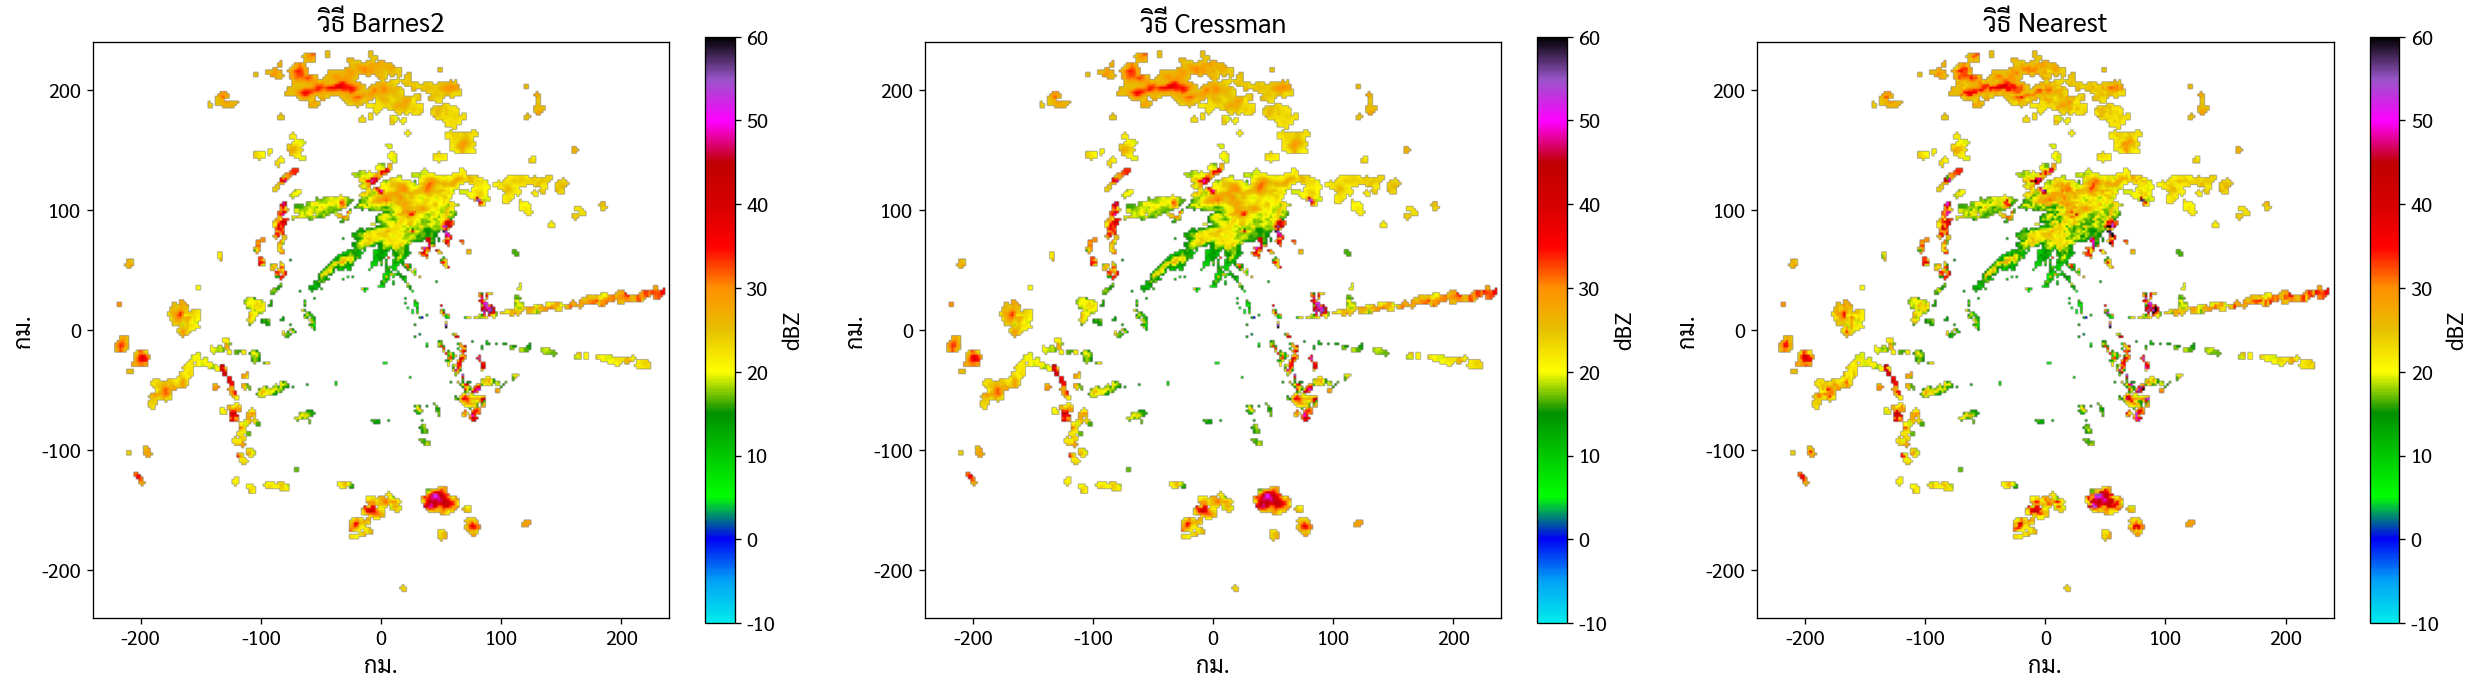

In [ ]:
methods = ['Barnes2', 'Cressman', 'Nearest']
results = {}
fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))
for ax, m in zip(axes, methods):
    g = make_grid(n_xy=241, nz=1, zlim=(2000.,2000.), weighting=m)
    arr = np.ma.filled(g.fields['reflectivity']['data'][0], np.nan)
    results[m] = arr
    show(ax, arr, f'วิธี {m}')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A6_interp_methods.png'), dpi=200, bbox_inches='tight')
plt.show()

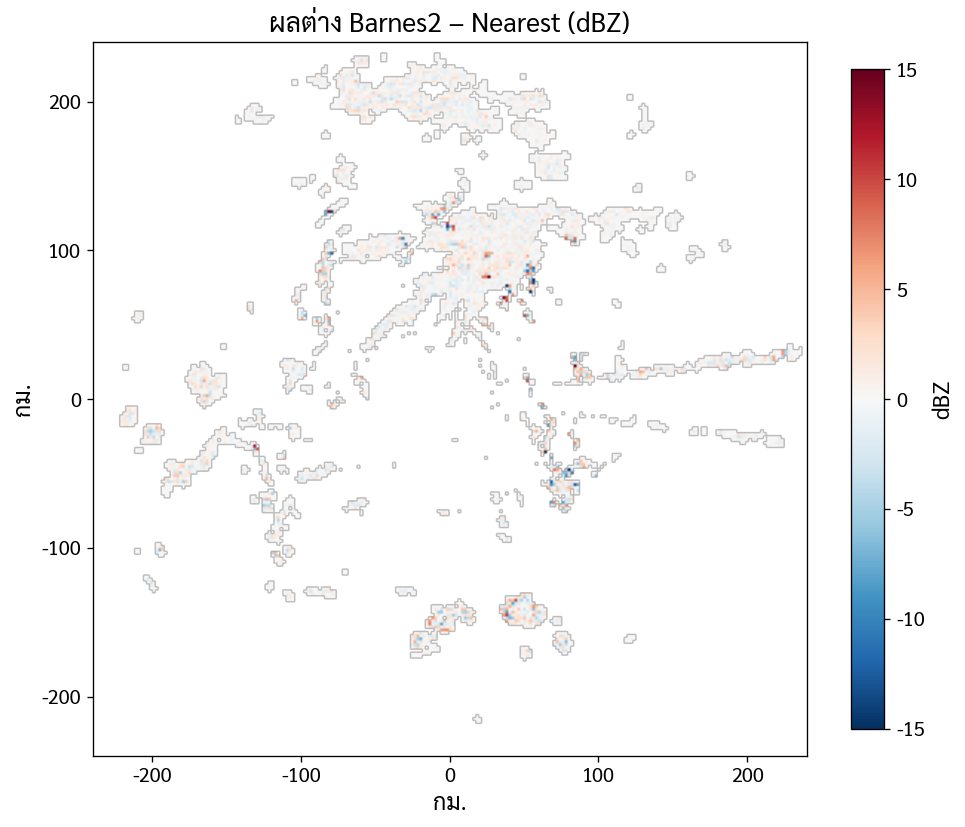

Barnes2 เรียบกว่า (เฉลี่ยเพื่อนบ้าน) ส่วน Nearest คมแต่เป็นบล็อก — ผลต่างมากที่ขอบ echo


In [ ]:
# แผนที่ผลต่างระหว่างวิธี (Barnes2 - Nearest)
diff = results['Barnes2'] - results['Nearest']
fig, ax = plt.subplots(figsize=(8.5, 7.5))
pm = ax.imshow(diff, origin='lower', extent=[-240,240,-240,240], cmap='RdBu_r', vmin=-15, vmax=15)
ax.set_title('ผลต่าง Barnes2 − Nearest (dBZ)'); ax.set_xlabel('กม.'); ax.set_ylabel('กม.'); ax.set_aspect('equal')
plt.colorbar(pm, ax=ax, shrink=0.8, label='dBZ')
plt.tight_layout(); plt.show()
print("Barnes2 เรียบกว่า (เฉลี่ยเพื่อนบ้าน) ส่วน Nearest คมแต่เป็นบล็อก — ผลต่างมากที่ขอบ echo")

**การแปลผล:** `Nearest` ให้ขอบคมเป็นบล็อก (ไม่เฉลี่ย), `Cressman`/`Barnes2` ให้ภาพเรียบต่อเนื่อง เหมาะกับงานเชิงพื้นที่มากกว่า


## A7 — ผลของรัศมีอิทธิพล (ROI) ต่างกัน


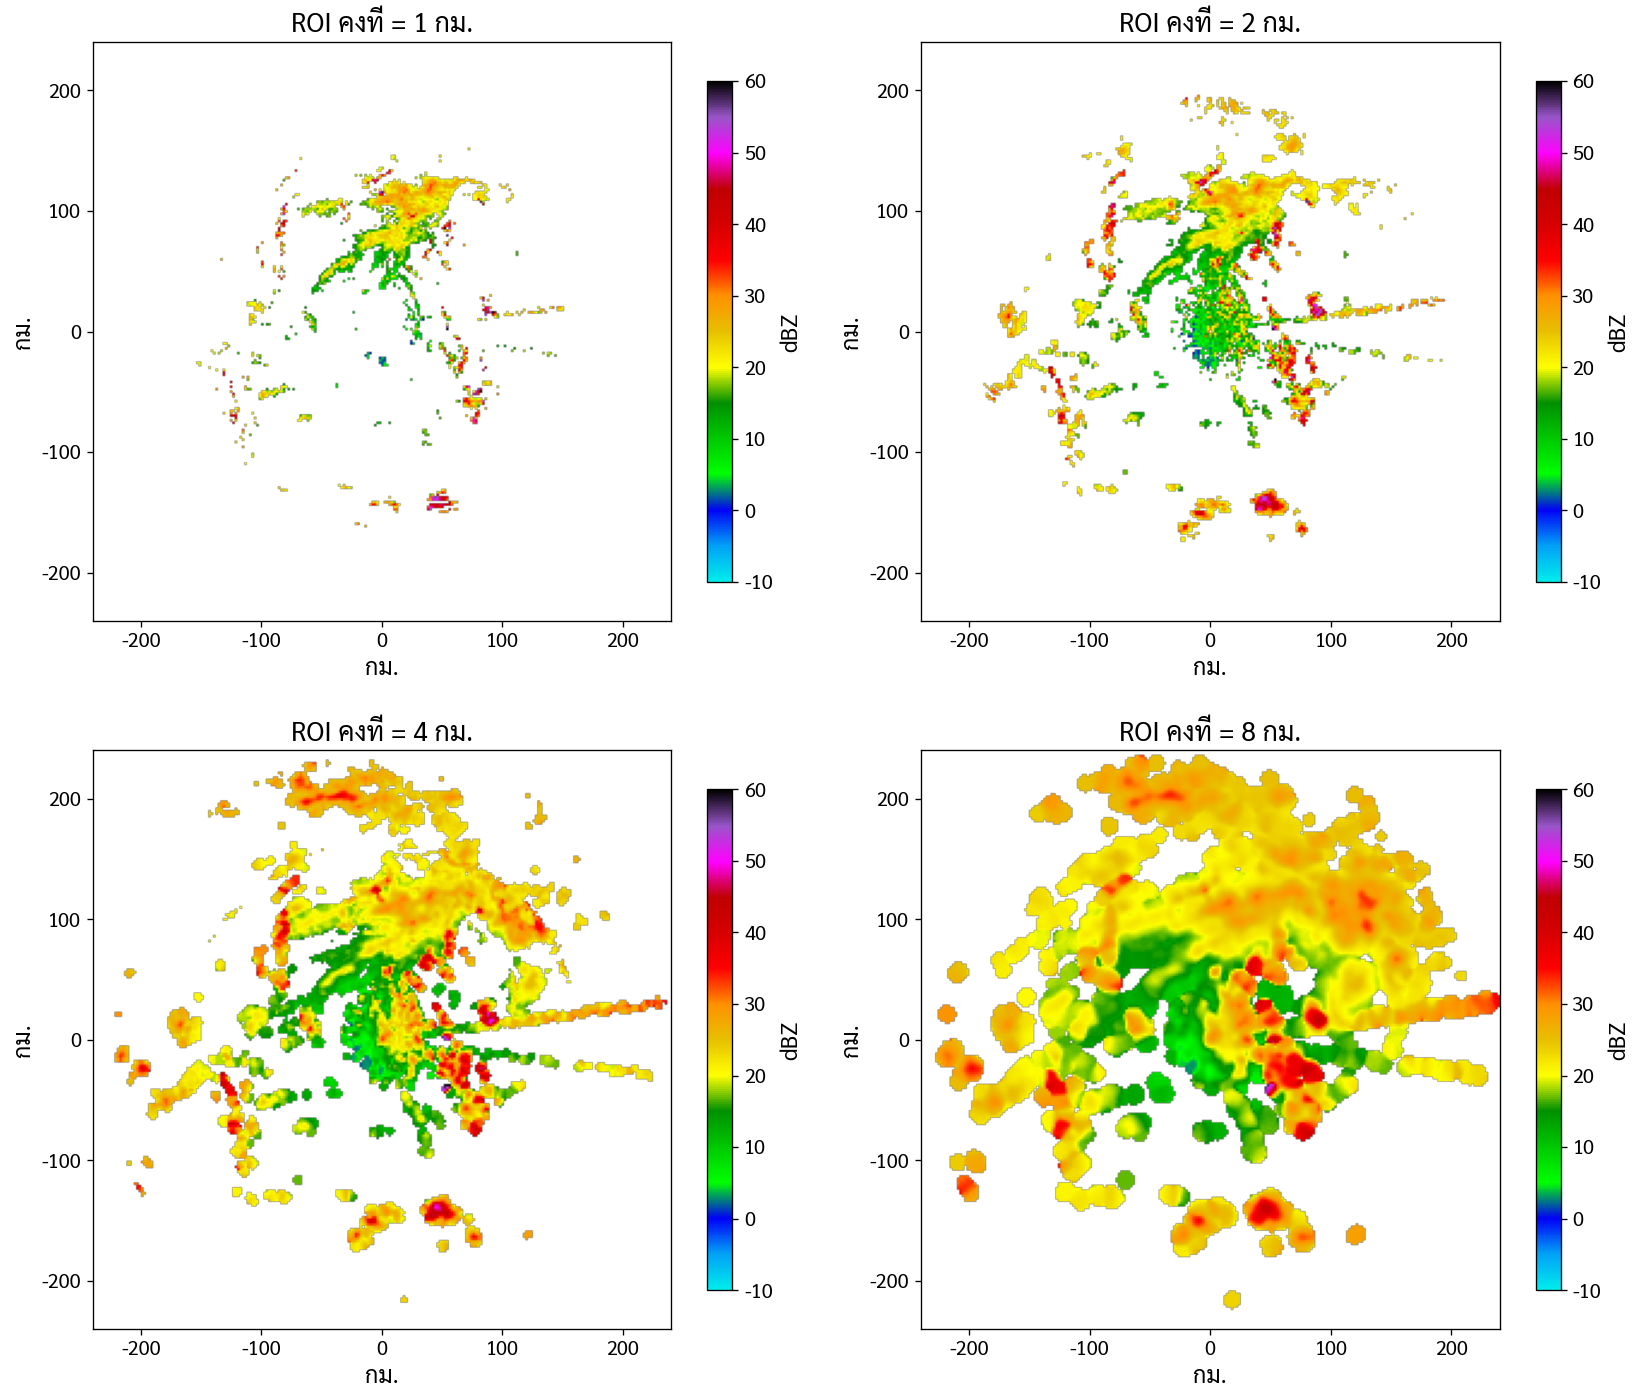

In [ ]:
rois = [1000., 2000., 4000., 8000.]   # เมตร
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, roi in zip(axes.flat, rois):
    g = make_grid(n_xy=241, nz=1, zlim=(2000.,2000.), roi_func='constant', constant_roi=roi)
    arr = np.ma.filled(g.fields['reflectivity']['data'][0], np.nan)
    show(ax, arr, f'ROI คงที่ = {roi/1000:.0f} กม.')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A7_roi_effect.png'), dpi=200, bbox_inches='tight')
plt.show()

**การแปลผล:** ROI เล็ก → คมชัดแต่มีรู/จุดว่าง (โดยเฉพาะระยะไกลที่ข้อมูลห่าง); ROI ใหญ่ → เรียบเนียนแต่รายละเอียดหาย


## A8 — ผลของความละเอียดกริด (และเวลาในการคำนวณ)


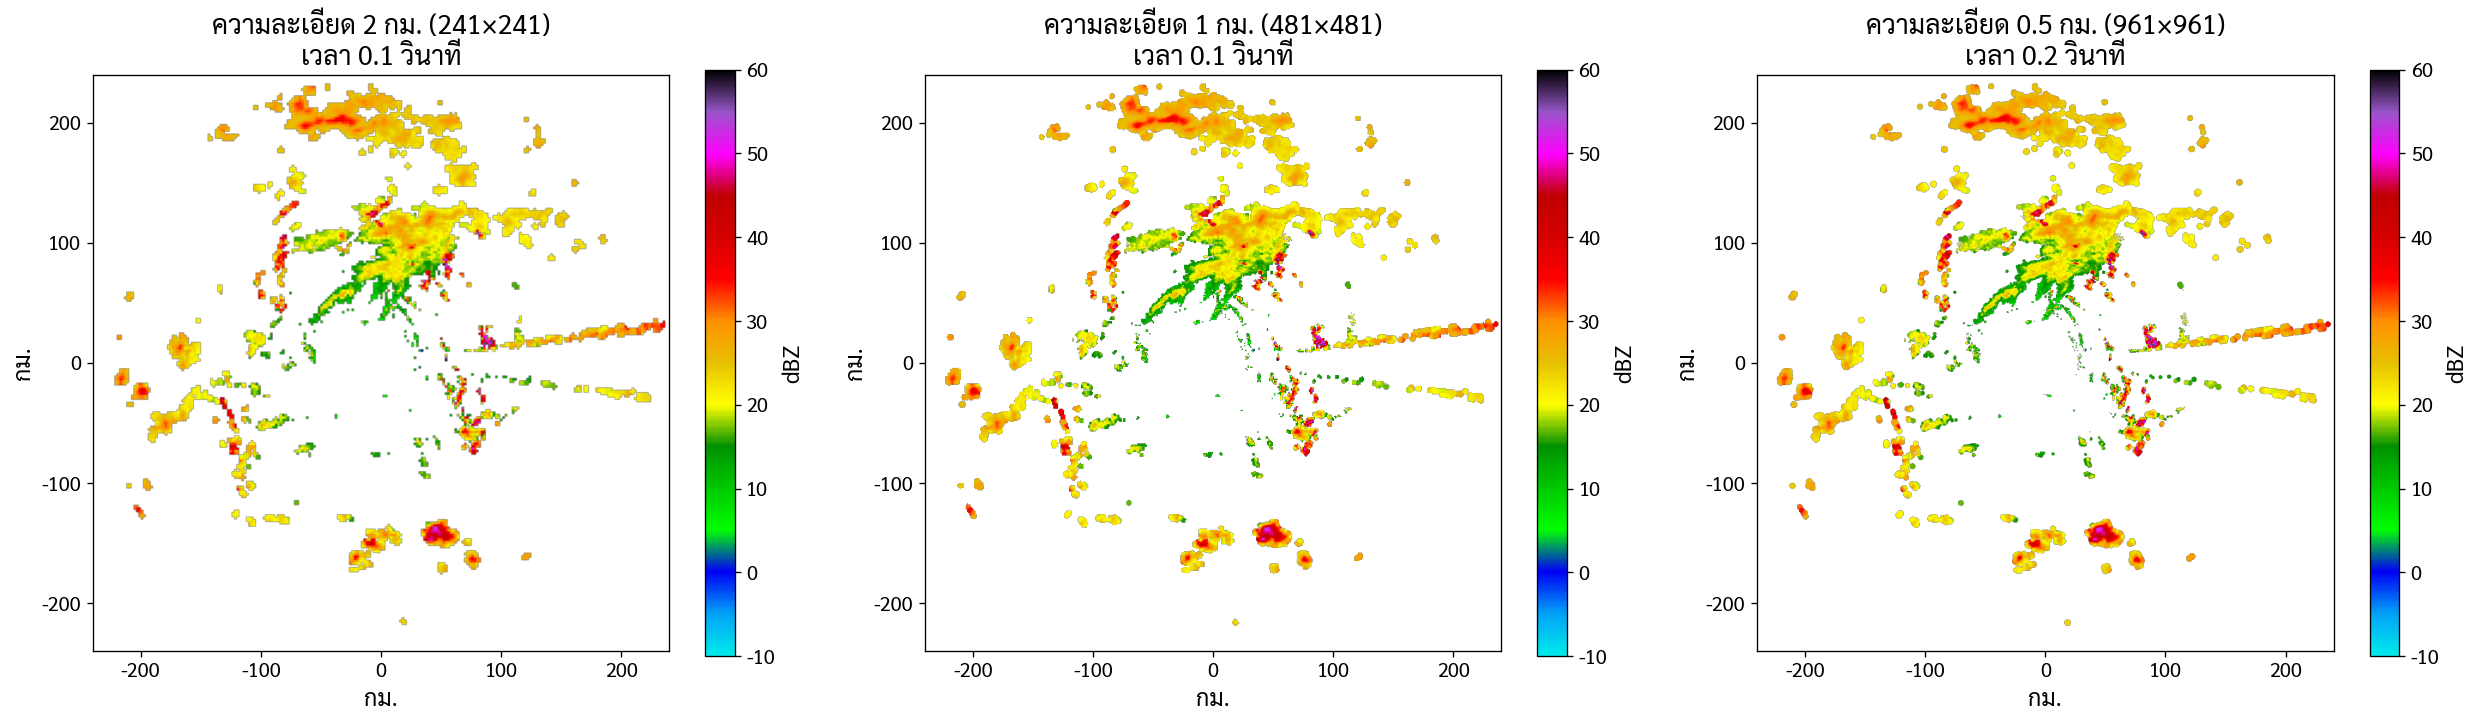

ยิ่งละเอียดยิ่งเห็นรายละเอียด แต่ใช้เวลา/หน่วยความจำมากขึ้นแบบกำลังสอง


In [ ]:
res_km = {241: '2 กม.', 481: '1 กม.', 961: '0.5 กม.'}
fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))
for ax, n in zip(axes, res_km):
    t0 = time.time()
    g = make_grid(n_xy=n, nz=1, zlim=(2000.,2000.))
    dt = time.time() - t0
    arr = np.ma.filled(g.fields['reflectivity']['data'][0], np.nan)
    show(ax, arr, f'ความละเอียด {res_km[n]} ({n}×{n})\nเวลา {dt:.1f} วินาที')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A8_resolution.png'), dpi=200, bbox_inches='tight')
plt.show()
print("ยิ่งละเอียดยิ่งเห็นรายละเอียด แต่ใช้เวลา/หน่วยความจำมากขึ้นแบบกำลังสอง")

**การแปลผล:** เลือกความละเอียดให้พอเหมาะกับงาน — สอนสด/สำรวจใช้ 2 กม.; งานตีพิมพ์/วิเคราะห์ละเอียดใช้ 1 กม. หรือ 0.5 กม.


## A9 — ผลิตภัณฑ์ Composite: Column-Max Reflectivity

ค่าสูงสุดตลอดคอลัมน์แนวดิ่ง = "composite reflectivity" ใช้ดูความรุนแรงสูงสุดของพายุในแต่ละจุด (นิยมใช้ในการเตือนภัย)


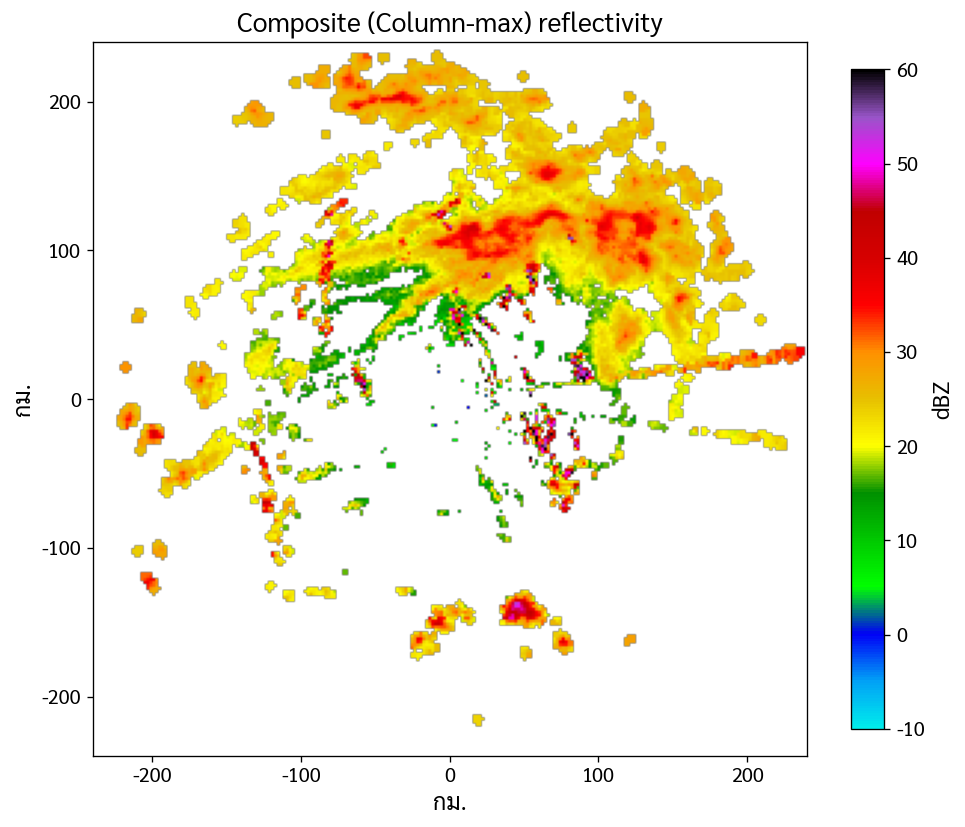

จุดที่ composite สูง = แกนพายุรุนแรง (รวมทุกระดับความสูง)


In [ ]:
colmax = np.nanmax(vol, axis=0)     # max ตามความสูง
fig, ax = plt.subplots(figsize=(8.5, 7.5))
show(ax, colmax, 'Composite (Column-max) reflectivity')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A9_composite.png'), dpi=200, bbox_inches='tight')
plt.show()
print("จุดที่ composite สูง = แกนพายุรุนแรง (รวมทุกระดับความสูง)")

## A10 — ภาพตัดแนวดิ่งตามเส้นที่เลือก (สะพานสู่บท 05)

ตัดกริด 3 มิติตามแนว N–S (คอลัมน์ x ที่เลือก) ผ่านแกนพายุ เพื่อดูโครงสร้างแนวดิ่ง — เชื่อมไปบท 05 (Cross-section & RHI)


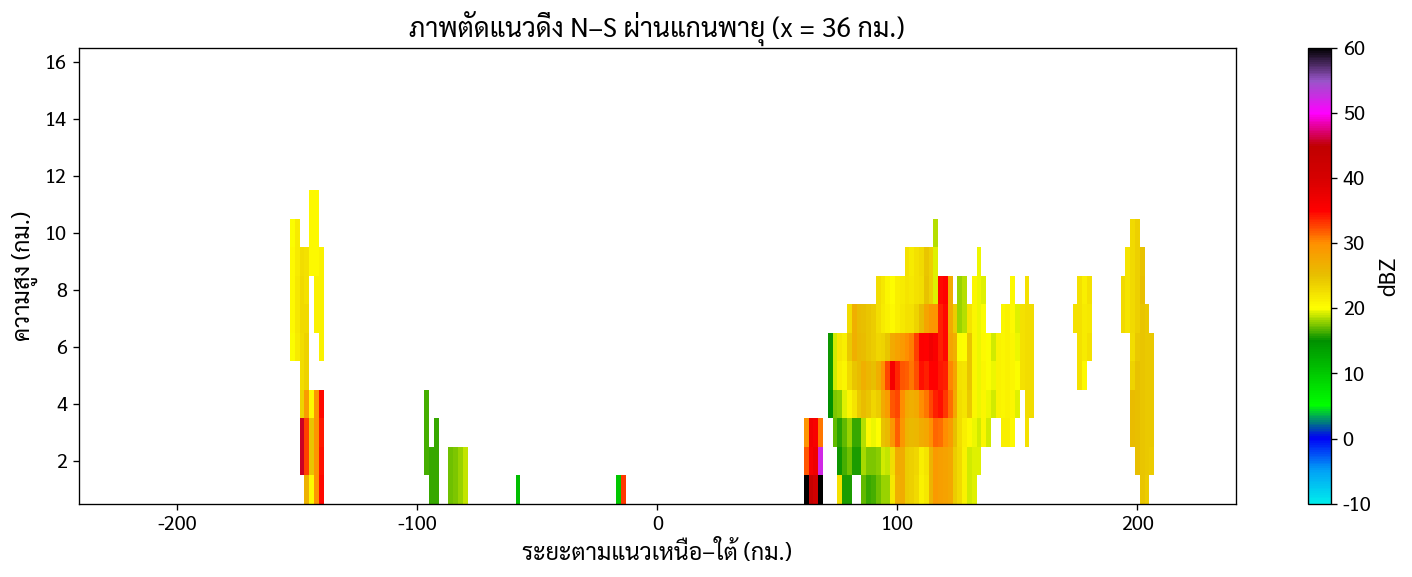

ความสูง echo top โดยประมาณ ณ แกนพายุ ≈ 3 กม.


In [ ]:
# หาแกนพายุจาก composite แล้วตัดแนว N–S ผ่านจุดนั้น
iy, ix = np.unravel_index(np.nanargmax(colmax), colmax.shape)
ykm = np.linspace(-240, 240, vol.shape[1])
yz = vol[:, :, ix]    # (nz, ny) ภาพตัดตามแนว N–S ที่ x = xkm[ix]

fig, ax = plt.subplots(figsize=(13, 5))
pm = ax.pcolormesh(ykm, zkm, np.ma.masked_invalid(yz), cmap='NWSRef', vmin=-10, vmax=60, shading='auto')
ax.set_xlabel('ระยะตามแนวเหนือ–ใต้ (กม.)'); ax.set_ylabel('ความสูง (กม.)')
ax.set_title(f'ภาพตัดแนวดิ่ง N–S ผ่านแกนพายุ (x = {xkm[ix]:.0f} กม.)')
plt.colorbar(pm, ax=ax, label='dBZ')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'A10_vertical_cross.png'), dpi=200, bbox_inches='tight')
plt.show()
print(f"ความสูง echo top โดยประมาณ ณ แกนพายุ ≈ {zkm[np.where(np.isfinite(yz[:, iy]))[0].max()]:.0f} กม.")

**การแปลผล:** เห็นแกนฝนหนักยกตัวในแนวดิ่ง และความสูงยอด echo — เป็นพื้นฐานของบท 05 ที่จะทำ cross-section/RHI อย่างละเอียด


## 📝 แบบฝึกหัด

1. เปลี่ยนระดับ CAPPI ที่ดึงใน A2 (เช่น 4, 6, 8 กม.) แล้วสังเกตว่าฝนหายไปที่ความสูงเท่าใด
2. ทดลอง `weighting='Cressman'` ร่วมกับ ROI คงที่ค่าต่าง ๆ (A6+A7) — วิธีใด/รัศมีใดเหมาะกับเหตุการณ์นี้
3. เลือกแนวตัด (A10) ผ่านบริเวณ **ฝนสตราติฟอร์ม** เทียบกับ **แกนพาความร้อน** — โครงสร้างแนวดิ่งต่างกันอย่างไร
4. (ต่อยอด) วัดเวลาในการ grid ที่ความละเอียดต่าง ๆ (A8) แล้วสรุปเป็นตาราง trade-off ความละเอียด–เวลา


In [ ]:
# แบบฝึกหัดข้อ 4 (โครงเริ่มต้น): ตาราง trade-off ความละเอียด–เวลา
import pandas as pd
rows = []
for n in [121, 241, 481]:
    t0 = time.time(); _ = make_grid(n_xy=n, nz=1, zlim=(2000.,2000.)); dt = time.time()-t0
    rows.append({'กริด (จุด)': f'{n}×{n}', 'ความละเอียด (กม.)': round(480/(n-1),2), 'เวลา (วินาที)': round(dt,2)})
pd.DataFrame(rows)
# TODO (นิสิต): ทำข้อ 1–3 ต่อ

,กริด (จุด),ความละเอียด (กม.),เวลา (วินาที)
0,121×121,4.0,0.19
1,241×241,2.0,0.17
2,481×481,1.0,0.20


---
## 🎯 สรุป

- Gridding แปลงข้อมูลโพลาร์เป็นกริดสม่ำเสมอ สร้าง CAPPI ได้หลายระดับจากกริด 3 มิติ
- **Cone of silence** เป็นข้อจำกัดเชิงเรขาคณิต เติมได้บางส่วนด้วย ROI ใหญ่/Nearest (เป็นการประมาณ)
- วิธี interpolation และ **รัศมี ROI/ความละเอียด** ควบคุมสมดุลระหว่างความคม–ความเรียบ–เวลา
- ผลิตภัณฑ์ต่อยอด เช่น composite reflectivity และภาพตัดแนวดิ่ง มาจากกริด 3 มิติ

**บทถัดไป — บทที่ 05:** Cross-section & RHI — เจาะลึกโครงสร้างแนวดิ่งของพายุ
